In [ ]:
!pip install tensorflow scikit-learn matplotlib seaborn

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'dataset.zip', 'sample_data']


In [ ]:
!unzip dataset.zip -d /content/dataset

Archive:  dataset.zip
   creating: /content/dataset/dataset/
   creating: /content/dataset/dataset/test/
   creating: /content/dataset/dataset/test/bird/
  inflating: /content/dataset/dataset/test/bird/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg  
  inflating: /content/dataset/dataset/test/bird/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg  
  inflating: /content/dataset/dataset/test/bird/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg  
  inflating: /content/dataset/dataset/test/bird/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg  
  inflating: /content/dataset/dataset/test/bird/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg  
  inflating: /content/dataset/dataset/test/bird/006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg  
  inflating: /content/dataset/dataset/test/bird/006f6769070fc876_jpg.rf.bda2b07a999cd589936497151e0d009f.jpg  
  inflating: /content/dataset/dataset/test/bird/007321d46c4b8ffe_jpg.

In [ ]:
print(os.listdir('/content/dataset/dataset'))

['valid', 'test', 'train']


In [ ]:
print(os.listdir('/content/dataset/dataset/train'))

['bird', 'drone']


In [ ]:
!mv /content/dataset/dataset/* /content/dataset/
!rm -r /content/dataset/dataset

In [ ]:
train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/valid"
test_dir  = "/content/dataset/test"

In [ ]:
train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/valid"
test_dir  = "/content/dataset/test"

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.2 MB/s eta 0:00:00


In [ ]:
import os

print(os.listdir('/content/dataset'))
print(os.listdir('/content/dataset/train'))

['valid', 'test', 'train']
['bird', 'drone']


In [ ]:
train_dir = "/content/dataset/train"
val_dir   = "/content/dataset/valid"
test_dir  = "/content/dataset/test"

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset.zip to dataset.zip


In [ ]:
!unzip dataset.zip -d /content/dataset

Archive:  dataset.zip
   creating: /content/dataset/dataset/
   creating: /content/dataset/dataset/test/
   creating: /content/dataset/dataset/test/bird/
  inflating: /content/dataset/dataset/test/bird/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg  
  inflating: /content/dataset/dataset/test/bird/00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg  
  inflating: /content/dataset/dataset/test/bird/0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg  
  inflating: /content/dataset/dataset/test/bird/00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg  
  inflating: /content/dataset/dataset/test/bird/004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jpg  
  inflating: /content/dataset/dataset/test/bird/006ce62a72df4dd4_jpg.rf.8f8e7b6e9a26a01be91ea1b7dc4011d2.jpg  
  inflating: /content/dataset/dataset/test/bird/006f6769070fc876_jpg.rf.bda2b07a999cd589936497151e0d009f.jpg  
  inflating: /content/dataset/dataset/test/bird/007321d46c4b8ffe_jpg.

In [ ]:
import os
print(os.listdir('/content/dataset/dataset'))

['train', 'valid', 'test']


In [ ]:
train_dir = "/content/dataset/dataset/train"
val_dir   = "/content/dataset/dataset/valid"
test_dir  = "/content/dataset/dataset/test"

['drone', 'bird']
Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.5228 - loss: 0.7121

84/84 ━━━━━━━━━━━━━━━━━━━━ 103s 868ms/step - accuracy: 0.5120 - loss: 0.7086 - val_accuracy: 0.4910 - val_loss: 0.6971
Epoch 2/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.5275 - loss: 0.6922

84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 446ms/step - accuracy: 0.5139 - loss: 0.6930 - val_accuracy: 0.4910 - val_loss: 0.6941
Epoch 3/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.5218 - loss: 0.6924

84/84 ━━━━━━━━━━━━━━━━━━━━ 37s 437ms/step - accuracy: 0.5312 - loss: 0.6919 - val_accuracy: 0.4910 - val_loss: 0.6940
Epoch 4/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5452 - loss: 0.6913

84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 424ms/step - accuracy: 0.5312 - loss: 0.6925 - val_accuracy: 0.4910 - val_loss: 0.6935
Epoch 5/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 421ms/step - accuracy: 0.5312 - loss: 0.6921 - val_accuracy: 0.4910 - val_loss: 0.6940
Epoch 6/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 430ms/step - accuracy: 0.5312 - loss: 0.6918 - val_accuracy: 0.4910 - val_loss: 0.6942
Epoch 7/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 431ms/step - accuracy: 0.5312 - loss: 0.6916 - val_accuracy: 0.4910 - val_loss: 0.6946
Epoch 8/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 36s 430ms/step - accuracy: 0.5312 - loss: 0.6915 - val_accuracy: 0.4910 - val_loss: 0.6948
Epoch 9/20
84/84 ━━━━━━━━━━━━━━━━━━━━ 35s 422ms/step - accuracy: 0.5312 - loss: 0.6914 - val_accuracy: 0.4910 - val_loss: 0.6953
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       121
           1       0.00      0.00      0.00        94

    accuracy                        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


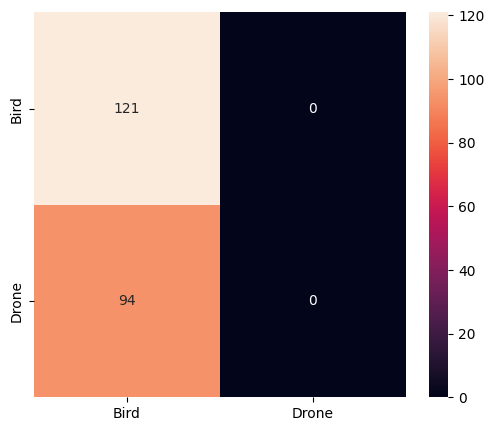

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# -------------------------
# PATHS (FINAL CORRECT)
# -------------------------
train_dir = "/content/dataset/dataset/train"
val_dir   = "/content/dataset/dataset/valid"
test_dir  = "/content/dataset/dataset/test"

# -------------------------
# VERIFY DATASET
# -------------------------
print(os.listdir(train_dir))  # should show ['bird', 'drone']

# -------------------------
# DATA GENERATORS
# -------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# -------------------------
# MODEL
# -------------------------
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# TRAIN
# -------------------------
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("/content/best_model.h5", save_best_only=True)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=callbacks
)

# -------------------------
# EVALUATION
# -------------------------
test_data.reset()
preds = model.predict(test_data)

y_pred = (preds > 0.5).astype(int).reshape(-1)
y_true = test_data.classes

print(classification_report(y_true, y_pred))

# -------------------------
# CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Bird','Drone'],
            yticklabels=['Bird','Drone'])
plt.show()

# -------------------------
# SAVE MODEL
# -------------------------
model.save("/content/bird_drone_model.h5")

In [ ]:
from google.colab import files
files.download('/content/bird_drone_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [ ]:
train_dir = "/content/dataset/dataset/train"
val_dir   = "/content/dataset/dataset/valid"
test_dir  = "/content/dataset/dataset/test"

In [ ]:
print(os.listdir(train_dir))

FileNotFoundError: [Errno 2] No such file or directory: '/content/dataset/dataset/train'

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7,1.3]
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.9413012729844413), 1: np.float64(1.0665064102564104)}


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

for layer in base_model.layers[-50:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 2,693,521 (10.27 MB)

 Non-trainable params: 1,525,267 (5.82 MB)

In [ ]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("/content/best_model.h5", save_best_only=True)
]

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 629ms/step - accuracy: 0.5124 - loss: 1.0166

84/84 ━━━━━━━━━━━━━━━━━━━━ 99s 786ms/step - accuracy: 0.5169 - loss: 0.9806 - val_accuracy: 0.4864 - val_loss: 0.6930
Epoch 2/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.5252 - loss: 0.8552 - val_accuracy: 0.4910 - val_loss: 0.6949
Epoch 3/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.5184 - loss: 0.8557 - val_accuracy: 0.4910 - val_loss: 0.7191
Epoch 4/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - accuracy: 0.5304 - loss: 0.7901 - val_accuracy: 0.4910 - val_loss: 0.7449
Epoch 5/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.5470 - loss: 0.8052

84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.5436 - loss: 0.7780 - val_accuracy: 0.5204 - val_loss: 0.6879
Epoch 6/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.5504 - loss: 0.7456

84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.5507 - loss: 0.7400 - val_accuracy: 0.5769 - val_loss: 0.6541
Epoch 7/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.5455 - loss: 0.7361 - val_accuracy: 0.5905 - val_loss: 0.6549
Epoch 8/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.5538 - loss: 0.7152

84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 454ms/step - accuracy: 0.5654 - loss: 0.7106 - val_accuracy: 0.5633 - val_loss: 0.6217
Epoch 9/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 450ms/step - accuracy: 0.5868 - loss: 0.6930 - val_accuracy: 0.5271 - val_loss: 0.7057
Epoch 10/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 453ms/step - accuracy: 0.5654 - loss: 0.6964 - val_accuracy: 0.5136 - val_loss: 0.8365
Epoch 11/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.5808 - loss: 0.6928

84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 457ms/step - accuracy: 0.5657 - loss: 0.6981 - val_accuracy: 0.6765 - val_loss: 0.6010
Epoch 12/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 451ms/step - accuracy: 0.5657 - loss: 0.6946 - val_accuracy: 0.5905 - val_loss: 0.6342
Epoch 13/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 452ms/step - accuracy: 0.5898 - loss: 0.6689 - val_accuracy: 0.5158 - val_loss: 0.9250
Epoch 14/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 447ms/step - accuracy: 0.5962 - loss: 0.6665 - val_accuracy: 0.5407 - val_loss: 0.7575
Epoch 15/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.6058 - loss: 0.6493

84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 456ms/step - accuracy: 0.5913 - loss: 0.6594 - val_accuracy: 0.7579 - val_loss: 0.5365
Epoch 16/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 449ms/step - accuracy: 0.5898 - loss: 0.6670 - val_accuracy: 0.5136 - val_loss: 0.8790
Epoch 17/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 450ms/step - accuracy: 0.6033 - loss: 0.6560 - val_accuracy: 0.5950 - val_loss: 0.5966
Epoch 18/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 444ms/step - accuracy: 0.6247 - loss: 0.6410 - val_accuracy: 0.5860 - val_loss: 0.6300
Epoch 19/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 444ms/step - accuracy: 0.6119 - loss: 0.6406 - val_accuracy: 0.6765 - val_loss: 0.6030
Epoch 20/25
84/84 ━━━━━━━━━━━━━━━━━━━━ 38s 451ms/step - accuracy: 0.5887 - loss: 0.6470 - val_accuracy: 0.6991 - val_loss: 0.5824


In [ ]:
test_data.reset()
preds = model.predict(test_data)

y_pred = (preds > 0.5).astype(int).reshape(-1)
y_true = test_data.classes

print(classification_report(y_true, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
              precision    recall  f1-score   support

           0       0.73      0.88      0.80       121
           1       0.79      0.59      0.67        94

    accuracy                           0.75       215
   macro avg       0.76      0.73      0.73       215
weighted avg       0.75      0.75      0.74       215



In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.2
)

val_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_data = val_gen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.9413012729844413), 1: np.float64(1.0665064102564104)}


In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze early layers, train deeper layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers[-100:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_8         │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_4     │ (None, 224, 224,  │          7 │ rescaling_8[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_9         │ (None, 224, 224,  │          0 │ normalization_4[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_9[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 3,825,141 (14.59 MB)

 Non-trainable params: 573,999 (2.19 MB)

In [ ]:
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ModelCheckpoint("/content/best_model.h5", save_best_only=True),
    ReduceLROnPlateau(patience=3, factor=0.3, verbose=1)
]

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=35,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.5533 - loss: 0.9161

84/84 ━━━━━━━━━━━━━━━━━━━━ 121s 928ms/step - accuracy: 0.5702 - loss: 0.8527 - val_accuracy: 0.5090 - val_loss: 0.6957 - learning_rate: 1.0000e-04
Epoch 2/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.5852 - loss: 0.8032

84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 507ms/step - accuracy: 0.5898 - loss: 0.7730 - val_accuracy: 0.5068 - val_loss: 0.6953 - learning_rate: 1.0000e-04
Epoch 3/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.5754 - loss: 0.7606

84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 507ms/step - accuracy: 0.5781 - loss: 0.7419 - val_accuracy: 0.5385 - val_loss: 0.6907 - learning_rate: 1.0000e-04
Epoch 4/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 501ms/step - accuracy: 0.5999 - loss: 0.6832 - val_accuracy: 0.4910 - val_loss: 0.6961 - learning_rate: 1.0000e-04
Epoch 5/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.6268 - loss: 0.6605

84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 506ms/step - accuracy: 0.6225 - loss: 0.6536 - val_accuracy: 0.5543 - val_loss: 0.6729 - learning_rate: 1.0000e-04
Epoch 6/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.6191 - loss: 0.6403

...

84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 500ms/step - accuracy: 0.6296 - loss: 0.6210 - val_accuracy: 0.7760 - val_loss: 0.5221 - learning_rate: 1.0000e-04
Epoch 9/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.6137 - loss: 0.6562

84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 507ms/step - accuracy: 0.6142 - loss: 0.6323 - val_accuracy: 0.7602 - val_loss: 0.4976 - learning_rate: 1.0000e-04
Epoch 10/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6371 - loss: 0.6031

84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 514ms/step - accuracy: 0.6390 - loss: 0.6025 - val_accuracy: 0.7670 - val_loss: 0.4970 - learning_rate: 1.0000e-04
Epoch 11/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 498ms/step - accuracy: 0.6495 - loss: 0.6067 - val_accuracy: 0.6719 - val_loss: 0.6240 - learning_rate: 1.0000e-04
Epoch 12/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 498ms/step - accuracy: 0.6589 - loss: 0.5952 - val_accuracy: 0.5249 - val_loss: 1.5315 - learning_rate: 1.0000e-04
Epoch 13/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.6458 - loss: 0.6118
Epoch 13: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.6551 - loss: 0.5965 - val_accuracy: 0.5294 - val_loss: 1.0059 - learning_rate: 1.0000e-04
Epoch 14/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 82s 493ms/step - accuracy: 0.6645 - loss: 0.5645 - val_accuracy: 0.5204 - val_loss: 0.9564 - learning_rate: 3.0000e-05
Epoch 15/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.65

84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 510ms/step - accuracy: 0.6510 - loss: 0.5763 - val_accuracy: 0.7783 - val_loss: 0.4485 - learning_rate: 3.0000e-05
Epoch 16/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 494ms/step - accuracy: 0.6728 - loss: 0.5742 - val_accuracy: 0.7195 - val_loss: 0.4795 - learning_rate: 3.0000e-05
Epoch 17/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 495ms/step - accuracy: 0.6582 - loss: 0.5645 - val_accuracy: 0.6154 - val_loss: 0.6208 - learning_rate: 3.0000e-05
Epoch 18/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.6719 - loss: 0.5548
Epoch 18: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 498ms/step - accuracy: 0.6657 - loss: 0.5572 - val_accuracy: 0.6674 - val_loss: 0.5637 - learning_rate: 3.0000e-05
Epoch 19/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 504ms/step - accuracy: 0.6657 - loss: 0.5543 - val_accuracy: 0.6833 - val_loss: 0.5225 - learning_rate: 9.0000e-06
Epoch 20/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.688

84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 503ms/step - accuracy: 0.6878 - loss: 0.5376 - val_accuracy: 0.7828 - val_loss: 0.4327 - learning_rate: 9.0000e-06
Epoch 21/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.6769 - loss: 0.5639 - val_accuracy: 0.7240 - val_loss: 0.4823 - learning_rate: 9.0000e-06
Epoch 22/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.6743 - loss: 0.5544 - val_accuracy: 0.7851 - val_loss: 0.4372 - learning_rate: 9.0000e-06
Epoch 23/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.6695 - loss: 0.5490
Epoch 23: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.
84/84 ━━━━━━━━━━━━━━━━━━━━ 43s 507ms/step - accuracy: 0.6762 - loss: 0.5534 - val_accuracy: 0.7489 - val_loss: 0.4679 - learning_rate: 9.0000e-06
Epoch 24/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 502ms/step - accuracy: 0.6818 - loss: 0.5481 - val_accuracy: 0.6923 - val_loss: 0.5071 - learning_rate: 2.7000e-06
Epoch 25/35
84/84 ━━━━━━━━━━━━━━━━━━━━ 42s 501ms/step - accuracy: 0.6

In [ ]:
test_data.reset()
preds = model.predict(test_data)

y_pred = (preds > 0.5).astype(int).reshape(-1)
y_true = test_data.classes

print(classification_report(y_true, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       121
           1       0.80      0.78      0.79        94

    accuracy                           0.82       215
   macro avg       0.82      0.81      0.82       215
weighted avg       0.82      0.82      0.82       215



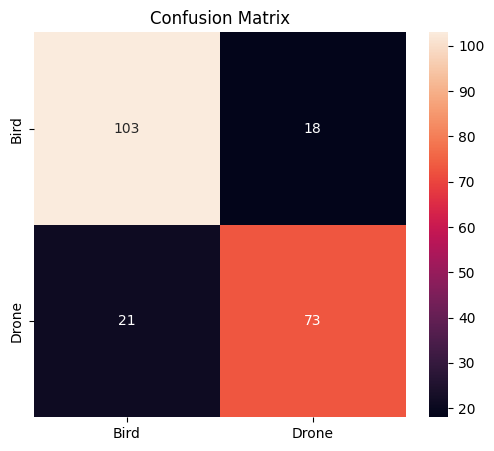

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Bird','Drone'],
            yticklabels=['Bird','Drone'])
plt.title("Confusion Matrix")
plt.show()

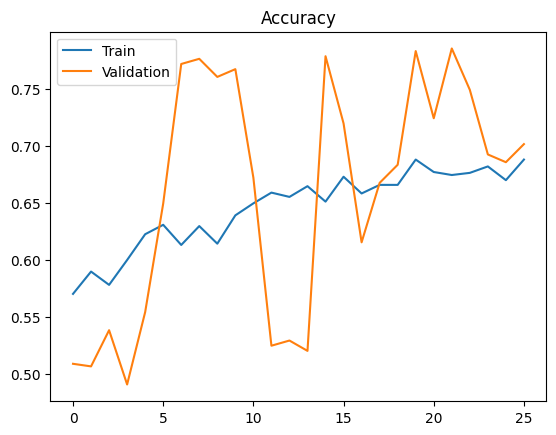

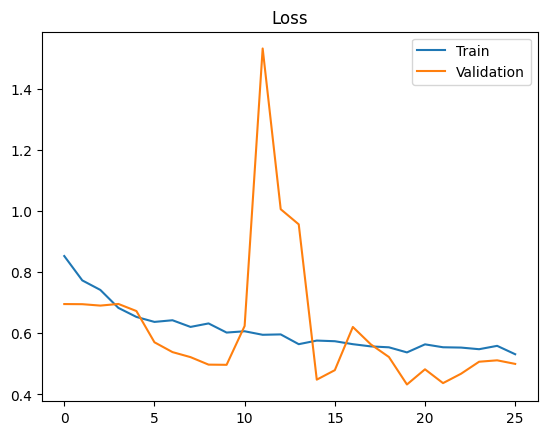

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")
plt.show()

In [ ]:
model.save("/content/bird_drone_model2.h5")

In [ ]:
from google.colab import files
files.download('/content/bird_drone_model2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
data_yaml = """
path: /content/dataset/dataset

train: train/images
val: valid/images
test: test/images

names:
  0: bird
  1: drone
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!unzip dataset.zip -d /content/

Archive:  dataset.zip
replace /content/dataset/test/bird/00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
data_yaml = """
path: r"D:\Guvi\Projects\dataset"

train: train/images
val: valid/images
test: test/images

names:
  0: bird
  1: drone
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

<>:2: SyntaxWarning: invalid escape sequence '\G'
<>:2: SyntaxWarning: invalid escape sequence '\G'
/tmp/ipykernel_480/3050410050.py:2: SyntaxWarning: invalid escape sequence '\G'
  path: r"D:\Guvi\Projects\dataset"
